In [1]:
# importamos librerías
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Configuración visual
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# EDA

In [3]:
# descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [4]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7237,7238,15753550,Levien,684,France,Female,43,7,0.00,2,1,0,131093.99,0
4131,4132,15738634,Yuan,533,France,Male,47,9,83347.25,1,1,1,137696.25,0
3321,3322,15681327,Akhtar,682,France,Male,30,9,0.00,2,1,1,2053.42,0
6701,6702,15629390,Liao,653,France,Male,37,7,135847.47,1,1,0,144880.81,0
6242,6243,15673333,Wilson,698,Germany,Male,52,8,96781.39,1,1,1,153373.71,0
2761,2762,15573280,Gallagher,646,Germany,Male,50,6,145295.31,2,1,1,27814.74,0
8878,8879,15675794,Hsing,645,Germany,Male,47,9,152076.93,1,1,0,121840.20,1
922,923,15753337,Yeates,555,France,Male,51,5,0.00,3,1,0,189122.89,1
8559,8560,15570857,Kambinachi,677,Germany,Female,39,0,111213.64,2,1,1,147578.26,0
312,313,15674398,Russo,642,France,Male,38,3,0.00,2,0,0,171463.83,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


Separamos datos categóricos de numéricos

In [6]:
# columnas categóricas
categorical_cols = df.select_dtypes(
    include=["str", "category", "bool"]
).columns.tolist()

categorical_cols

['Surname', 'Geography', 'Gender']

In [7]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols

['RowNumber',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [8]:
#Exluimos 2 que no sirven para los histogramas
num_excluir = ["RowNumber", "CustomerId"]
numeric_cols = [col for col in numeric_cols if col not in num_excluir]

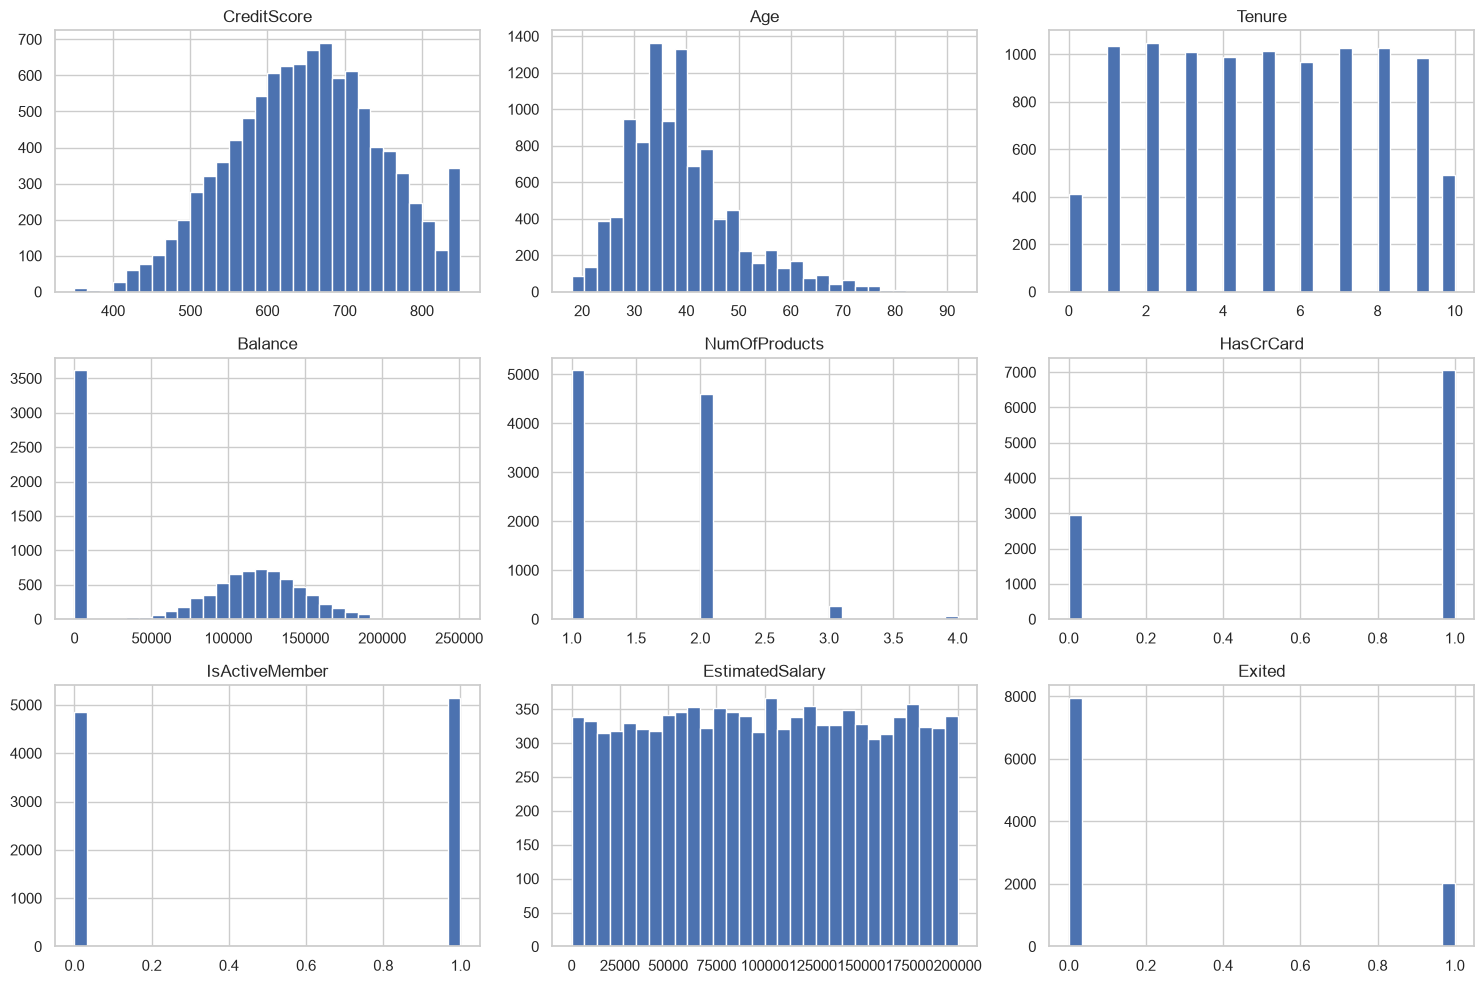

In [9]:
df[numeric_cols].hist(
    figsize=[15,10],
    bins=30
)
plt.tight_layout()
plt.show()

#### Observaciones básicas de las columnas numéricas
* El rango de edad más común de los clientes está entre 35 y 40 años.
* Hay una distribución pareja entre los años de antigüedad (Tenure), aunque hay una pequeña cantidad que tiene 10 años. 
* Un gran porcentaje de los clientes tiene su balance en 0. Puede significar que no usan el banco como caja de ahorro.
* La mayoría tiene entre 1 y 2 productos. Muy pocos 3 o 4.
* El 70% sí tiene tarjeta de crédito.
* (hay que revisar qué implica que sea Active) Casi se divide entre mitad y mitad entre miembros activos y no activos. 
* El salario no tiene grandes diferencias. 
* El 80% no abandonó. El 20% sí. 

## Tratamiento de valores faltantes básico

### Nulos

In [10]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

No hay valores nulos. 

### Duplicados

Verificamos que no haya duplicados en los ID de los clientes, ya que solo necesitamos una fila por cliente

In [11]:
df.duplicated('CustomerId').sum()

np.int64(0)

No existen duplicados del ID de las personas, por tanto, cada fila es de una persona distinta

### Errores
Verificamos datos que no sean adecuados, para eliminarlos o imputarlos. Por ejemplo si los valores que deberían ser 0 o 1 tienen otros valores. 

In [12]:
display(df['HasCrCard'].unique()) 
display(df['IsActiveMember'].unique()) 
display(df['Exited'].unique()) 


array([1, 0])

array([1, 0])

array([1, 0])

Todos tienen valores correctos (entre sí 1 y no 0)

### Desbalanceo de clases
Analizar qué porcentaje del total han abandonado el banco.

In [13]:
df["Exited"].value_counts(1)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Hay una gran diferencia, prácticamente un 80% no ha dejado el banco. Hay que tener en cuenta esto al entrenar el modelo. 

## Exploraciones básicas

### Variables demográficas

#### Género

In [14]:
# por género
df.groupby("Gender")["Exited"].value_counts(normalize=True).unstack() * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


El 25% de mujeres ha salido del banco. Mientras que solo el 16% de los hombres. En general la proporcion es 80/20, pero viendo más de cerca analizando por sexo, hay algunas diferencias. 

#### País

In [15]:
# por ciudad
df.groupby("Geography")["Exited"].value_counts(normalize=True).unstack() * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


En España y Francia se da que solo un 16% deja el banco, mientras que en Alemania se da el doble. Un 32% deja el banco. Esto llama la atención. ¿Qué está pasando en Alemania?

#### Edad

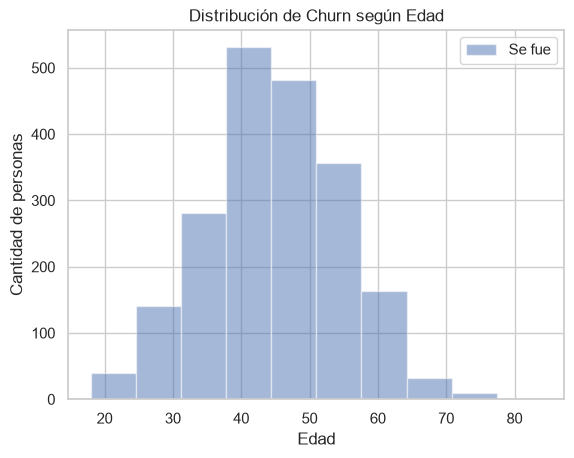

In [16]:
df[df['Exited']==1]['Age'].hist(alpha=0.5, label='Se fue', bins=10) # evaluamos con histograma para ver rangos.
plt.legend()
plt.xlabel('Edad')
plt.ylabel('Cantidad de personas')
plt.title('Distribución de Churn según Edad')
plt.show()

El rango de edad con más tasa de Churn está entre los 40 y 50 años. 

#### Credit Score
¿Hay correlación entre cierto CS y los que se van?

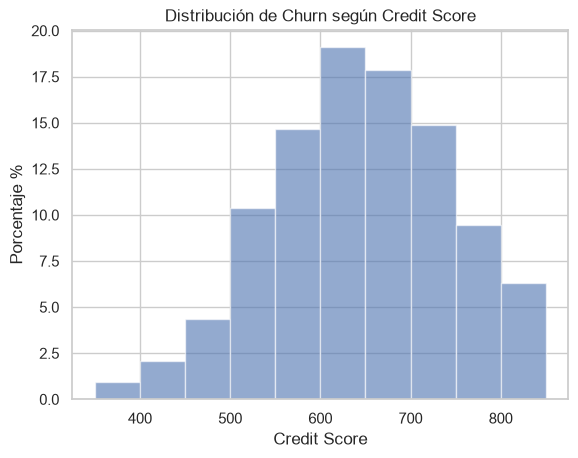

In [17]:
data = df[df['Exited']==1]['CreditScore']
weights = np.ones(len(data)) / len(data) * 100 

data.hist(alpha=0.6, label='Se fue', bins=10, weights=weights) # evaluamos con histograma
plt.xlabel('Credit Score')
plt.ylabel('Porcentaje %')
plt.title('Distribución de Churn según Credit Score')
plt.show()

#### Correlaciones varias

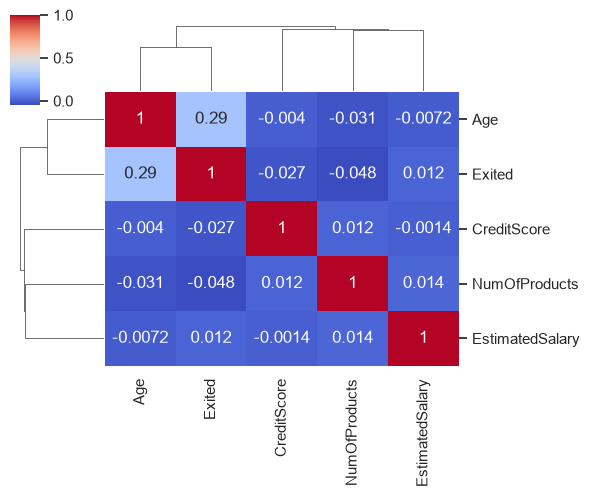

In [18]:
variables_interes = ['Age', 'NumOfProducts', 'EstimatedSalary', 'Exited', 'CreditScore']
df_vars = df[variables_interes]
corr = df_vars.corr()
# Armamos mapa de calor con SeaBorn
sns.clustermap(corr, annot=True, figsize=(6,5), cmap='coolwarm')
plt.show()

No hay ninguna correlación relevante con estas variables. No hay multicolinealidad

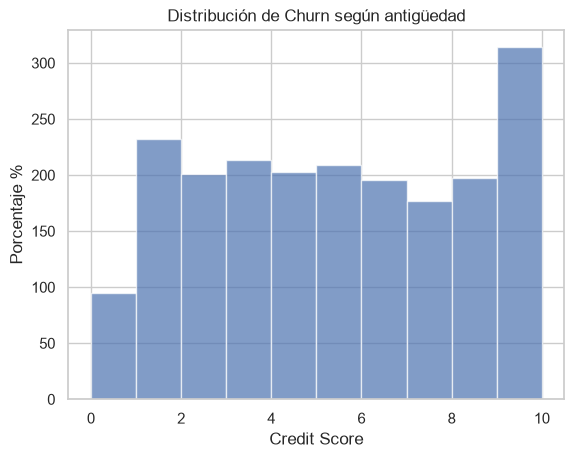

In [19]:
data = df[df['Exited']==1]['Tenure']
data.hist(alpha=0.7, label='Se fue', bins=10) # evaluamos con histograma
plt.xlabel('Credit Score')
plt.ylabel('Porcentaje %')
plt.title('Distribución de Churn según antigüedad')
plt.show()

# Preparación de datos para regresión logística

## Encoding
### Dividir el dataset en train y test

In [20]:
# seleccionamos primero solo las columnas que nos van a servir más
subset = [
'RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'
]

In [21]:
# definimos las features y el target
X = df[subset] # features
y = df['Exited'] # target

In [22]:
# dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # qué porcentaje del dataset destinaremos para testear
    random_state=42,
    stratify=y              # la variable objetivo, que es Exited
)

print("X_train:", X_train.shape)
print(y_train.value_counts(1))

print("X_test:", X_test.shape)
print(y_test.value_counts(1))


X_train: (8000, 13)
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64
X_test: (2000, 13)
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


### Preprocesamiento

Volvamos a establecer las variables categóricas y las numéricas

In [23]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [24]:
numeric_cols = [
'RowNumber',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary'
]

categorical_cols = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember'
]

#### Imputación de variables numéricas

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline_numeric = Pipeline(
    [
        ('imputter', SimpleImputer(strategy='median')),
        ('transform', StandardScaler())
    ]
)
pipeline_numeric

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputter', ...), ('transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accoun

In [26]:
# ahora a hacer el fit (entrenar)
pipeline_numeric.fit(X_train[numeric_cols])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputter', ...), ('transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['RowNumber','CustomerId','CreditScore',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings 

In [27]:
# creamos los dataframes
df_train_num_trans = pd.DataFrame(
    pipeline_numeric.transform(X_train[numeric_cols]),
    columns= numeric_cols
)

df_test_num_trans = pd.DataFrame(
    pipeline_numeric.transform(X_test[numeric_cols]),
    columns= numeric_cols
)

In [28]:
display(df_train_num_trans.head())
display(df_test_num_trans.head())

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-0.980020,-1.421678,1.058568,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084
1,1.174797,-0.691207,0.913626,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556
2,0.005720,0.822118,1.079274,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128
3,-0.301223,-0.374156,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199
4,0.757023,-1.631516,0.427035,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0.246027,0.815528,-0.680735,-0.279932,0.684723,-1.226059,0.808830,0.641042,-1.030206,-0.095021
1,-0.456594,1.619068,-1.301915,-0.564935,-0.350971,0.877113,0.808830,-1.559960,-1.030206,-0.778941
2,-1.164393,1.531791,-0.970619,0.100072,-0.350971,-1.226059,0.808830,-1.559960,0.970680,0.099469
3,0.236014,-1.641511,-0.121674,-0.469934,-0.005739,1.011458,0.808830,-1.559960,-1.030206,-1.147374
4,-0.247707,-1.253546,-0.111321,-0.469934,-0.696202,0.023204,-0.910256,0.641042,0.970680,1.200283


#### Imputación de variables categóricas

In [29]:
from sklearn.preprocessing import OneHotEncoder

pipeline_categorical = Pipeline(
    [
        ('imputter', SimpleImputer(strategy='most_frequent')),
        ('transform', OneHotEncoder(handle_unknown='ignore', min_frequency=0.05, sparse_output=False))
    ]
)
pipeline_categorical

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputter', ...), ('transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto

In [30]:
pipeline_categorical.fit(X_train[categorical_cols])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputter', ...), ('transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Geography','Gender','HasCrCard','IsActiveMember']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy c

In [31]:
# creamos 
df_train_cat_trans = pd.DataFrame(
    pipeline_categorical.transform(X_train[categorical_cols]),
    columns = pipeline_categorical.named_steps['transform'].get_feature_names_out(categorical_cols)
)

df_test_cat_trans = pd.DataFrame(
    pipeline_categorical.transform(X_test[categorical_cols]),
    columns = pipeline_categorical.named_steps['transform'].get_feature_names_out(categorical_cols)
)

In [32]:
display(df_train_cat_trans.head())
display(df_test_cat_trans.head())

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


#### Unimos ambos DF

In [33]:
X_train_trans = pd.concat(
    [
        df_train_num_trans,
        df_train_cat_trans
    ],
    axis = 1
)

X_test_trans = pd.concat(
    [
        df_test_num_trans,
        df_test_cat_trans
    ],
    axis = 1
)

In [34]:
X_train_trans.sample()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0,HasCrCard_1,IsActiveMember_0,IsActiveMember_1
3580,-0.894048,-1.154577,0.623742,-0.469934,-0.350971,0.916344,0.80883,0.641042,0.97068,-0.989929,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


# Entrenar un modelo

In [70]:
# crear el modelo
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=100000,
    class_weight='balanced',
)

In [71]:
# entrenar
# todo lo que hicimos hasta ahora en X_train_trans, no hace falta con y, porque era solo Exited o no.
logistic_model.fit(X_train_trans, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",100000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

# Generar predicciones

In [72]:
y_train_log_pred = logistic_model.predict(X_train_trans) # es como hacer la fórmula de la reg. logística. 
y_test_log_pred = logistic_model.predict(X_test_trans)
y_test_log_proba = logistic_model.predict_proba(X_test_trans)[:,1] # le digo que solo me interesa las probabilidades de "1", de que haya Exited.

# Evaluar el modelo
Usaremos f1_score para evaluar la precisión del modelo al generar predicciones. 


In [73]:
from sklearn.metrics import f1_score

In [74]:
# Con f1_score
train_f1_logistic = f1_score(y_train, y_train_log_pred)
test_f1_logistic = f1_score(y_test, y_test_log_pred)

print(f"Train f1 log: {train_f1_logistic:.3f}")
print(f"Test f1 log:  {test_f1_logistic:.3f}")

Train f1 log: 0.492
Test f1 log:  0.500


Antes de aplicar class_weight: 'balanced' me estaba saliendo:

Train f1 log: 0.317
Test f1 log:  0.286

<Axes: >

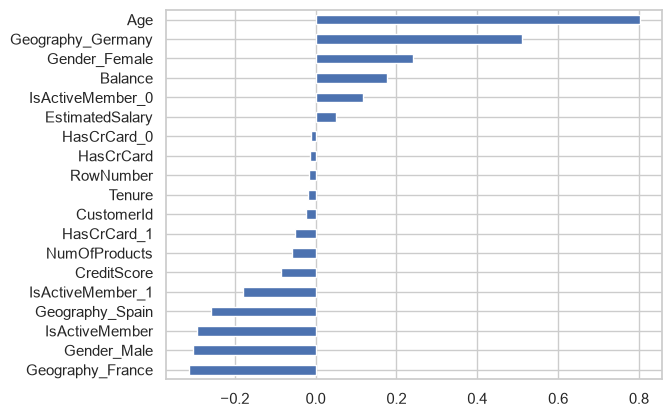

In [75]:
# hacemos el gráfico
pd.Series(
    logistic_model.coef_[0],
    index = X_train_trans.columns   
).sort_values().plot(kind='barh')

Según esto, lo que más influencia tiene en la tasa de Churn es la edad. 

# Apartado: Probamos con otro modelo

## Decision Tree

In [55]:
# DecisionTree
from sklearn.tree import DecisionTreeClassifier

In [58]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_leaf=0.05,
    class_weight='balanced'
)

dt.fit(X_train_trans, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [59]:
y_train_dt_pred = dt.predict(X_train_trans)
y_test_dt_pred = dt.predict(X_test_trans)
y_test_dt_proba = dt.predict_proba(X_test_trans)[:  , 1]

In [60]:
# Evaluamos el modelo Decision Tree ahora
train_f1_dt = f1_score(y_train, y_train_dt_pred)
test_f1_dt = f1_score(y_test, y_test_dt_pred)

print(f"Train f1 dt: {train_f1_dt:.3f}")
print(f"Test f1 dt:  {test_f1_dt:.3f}")

Train f1 dt: 0.510
Test f1 dt:  0.502


<Axes: >

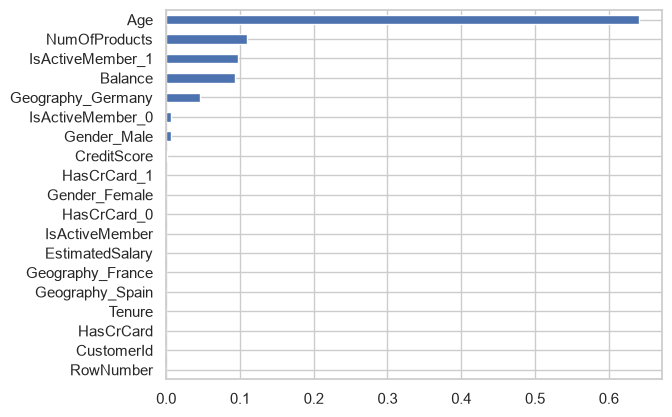

In [61]:
pd.Series(
    dt.feature_importances_,
    index = X_train_trans.columns
).sort_values().plot(kind='barh')

---

In [46]:
df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [47]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8311,8312,15589698,De Luca,555,Germany,Male,42,6,107104.50,1,1,1,41304.44,1
5273,5274,15733904,McDonald,529,France,Male,32,9,147493.89,1,1,0,33656.35,0
3485,3486,15728456,Martinez,604,France,Male,33,3,0.00,1,1,0,42171.13,1
8464,8465,15568164,Istomin,850,France,Female,34,4,71379.53,2,1,1,154000.99,0
9690,9691,15791674,Sutherland,846,France,Female,34,10,142388.61,2,0,1,68393.64,1
6959,6960,15705403,Seleznyova,617,Spain,Female,46,3,106521.49,1,0,1,86587.37,0
1201,1202,15651052,McMasters,399,Germany,Male,46,2,127655.22,1,1,0,139994.68,1
2881,2882,15570943,Artemyeva,711,Germany,Female,35,2,133607.75,1,1,1,120586.32,0
8309,8310,15599976,Bellasis,749,France,Female,27,9,0.00,2,1,0,132734.87,0
3425,3426,15802207,Ibezimako,769,Germany,Male,43,4,110182.54,2,1,1,87537.32,0
